In [36]:
import sys, os
sys.path.insert(1, os.path.realpath(os.path.pardir))
from specs import *
import pandas as pd
from scipy.optimize import curve_fit
from scipy.stats import t
from matplotlib.transforms import ScaledTranslation
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "Helvetica"
})

rawDir = "/Users/jiyong/data/0804_container_detector_data/"
pn1Dir = rawDir + "P1_SN1222/"
pn2Dir = rawDir + "P2_SN1215/"
pn1files0 = [f for f in listdir(pn1Dir) if isfile(join(pn1Dir, f)) and f.endswith('mca')]
pn2files0 = [f for f in listdir(pn2Dir) if isfile(join(pn2Dir, f)) and f.endswith('mca')]

pn1files = [None] * len(pn1files0)
pn2files = [None] * len(pn2files0)

for f1 in pn1files0:
    ddd = (f1[1:-4].split("_"))[-1]
    if ddd == "BKG":
        pn1files[0] = pn1Dir+f1
    else :
        q = int(ddd.split("-")[-1])
        pn1files[q] = pn1Dir+f1
for f2 in pn2files0:
    ddd = (f2[1:-4].split("_"))[-1]
    if ddd == "BKG":
        pn2files[0] = pn2Dir+f2
    else :
        q = int(ddd.split("-")[-1])
        pn2files[q] = pn2Dir+f2


Log =[
    [0, ["Bkg"], 0, 0],                            # 0
    [1, ["Am241",], 80, 420],                      # 1
    [2, ["Am241",], 180, 320],                     # 2
    [3, ["Am241",], 280, 220],                     # 3
    [4, ["Am241",], 460, 40],                      # 4
    [5, ["Cs137",], 70, 430],                      # 5
    [6, ["Cs137",], 130, 370],                     # 6
    [7, ["Cs137",], 300, 200],                     # 7
    [8, ["Cs137",], 390, 110],                     # 8
    [9, ["Co60",], 60, 440],                       # 9
    [10, ["Co60",], 120, 380],                      # 10
    [11, ["Co60",], 310, 190],                      # 11
    [12, ["Co60",], 470, 30],                       # 12
    [13, ["Co60", "Cs137"], 136, 359],              # 13
    [14, ["Am241", "Co60"], 287, 208],              # 14
    [15, ["Co60", "Cs137"], 361, 134],              # 15
    [16, ["Am241", "Cs137"], 163, 332],
    [17, ["Am241", "Co60", "Cs137"], 309, 186],
    [18, ["Am241", "Co60",], 210, 285, 153, 342],
    [19, ["Co60", "Cs137"], 285, 210, 367, 128],
    [20, ["Am241", "Cs137"], 85, 410, 173, 322],
    [21, ["Co60", "Cs137"], 316, 179, 223, 272],
    [22, [None,], ],
]

# PN1 data

ni = 3
Specs1 = pd.DataFrame( {
    "bkg" : read_mca(pn1files[0])[ni:], 
    "am_80" : read_mca(pn1files[1])[ni:],
    "cs_70" : read_mca(pn1files[5])[ni:],
    "cs_130" : read_mca(pn1files[6])[ni:],
    "co_120" : read_mca(pn1files[10])[ni:],
    "co_60" :  read_mca(pn1files[9])[ni:],
    "co_cs_136" : read_mca(pn1files[13])[ni:],
    "am_co_287" : read_mca(pn1files[14])[ni:],
    "co_cs_361" : read_mca(pn1files[15])[ni:],
    "am_cs_163" : read_mca(pn1files[16])[ni:],
    "am_co_cs_309" : read_mca(pn1files[17])[ni:],
    "am_210_co_153" : read_mca(pn1files[18])[ni:],
    "co_285_cs_367" : read_mca(pn1files[19])[ni:],
    "am_85_cs_173" : read_mca(pn1files[20])[ni:],
    "co_316_cs_223" : read_mca(pn1files[21])[ni:]
        
})

# PN2 data
Specs2 = pd.DataFrame( {
    "bkg" : read_mca(pn2files[0])[ni:], 
    "am_80" : read_mca(pn2files[1])[ni:],
    "cs_70" : read_mca(pn2files[5])[ni:],
    "cs_130" : read_mca(pn2files[6])[ni:],
    "co_120" : read_mca(pn2files[10])[ni:],
    "co_60" :  read_mca(pn2files[9])[ni:],
    "co_cs_136" : read_mca(pn2files[13])[ni:],
    "am_co_287" : read_mca(pn2files[14])[ni:],
    "co_cs_361" : read_mca(pn2files[15])[ni:],
    "am_cs_163" : read_mca(pn2files[16])[ni:],
    "am_co_cs_309" : read_mca(pn2files[17])[ni:],
    "am_210_co_153" : read_mca(pn2files[18])[ni:],
    "co_285_cs_367" : read_mca(pn2files[19])[ni:],
    "am_85_cs_173" : read_mca(pn2files[20])[ni:],
    "co_316_cs_223" : read_mca(pn2files[21])[ni:]
        
})

SpecsRef = pd.DataFrame( {
    "bkg" : read_mca(pn2files[0])[ni:], 
    "am_80" : read_mca(pn2files[1])[ni:],
    "am_180" : read_mca(pn2files[2])[ni:],
    "am_280" : read_mca(pn2files[3])[ni:],
    "am_460" : read_mca(pn2files[4])[ni:],
    "co_60" :  read_mca(pn2files[9])[ni:],
    "co_120" :  read_mca(pn2files[10])[ni:],
    "co_310" :  read_mca(pn2files[11])[ni:],
    "co_470" :  read_mca(pn2files[12])[ni:],
    "cs_70" :  read_mca(pn2files[5])[ni:],
    "cs_130" :  read_mca(pn2files[6])[ni:],
    "cs_300" :  read_mca(pn2files[7])[ni:],
    "cs_390" :  read_mca(pn2files[8])[ni:],
    
})

In [2]:
Specs1

,bkg,am_80,cs_70,cs_130,co_120,co_60,co_cs_136,am_co_287,co_cs_361,am_cs_163,am_co_cs_309,am_210_co_153,co_285_cs_367,am_85_cs_173,co_316_cs_223
0,28962.0,39524.0,31115.0,29759.0,26560.0,24553.0,28652.0,29348.0,28976.0,33095.0,29483.0,29758.0,28408.0,38889.0,28534.0
1,10813.0,18165.0,17428.0,13797.0,11951.0,14062.0,14701.0,12270.0,11861.0,15361.0,12896.0,13338.0,12032.0,18940.0,12323.0
2,7426.0,11487.0,13680.0,10117.0,8772.0,10853.0,10920.0,8242.0,8292.0,10672.0,8876.0,9113.0,8255.0,12981.0,8719.0
3,5980.0,8588.0,12141.0,8562.0,7305.0,9338.0,9409.0,6591.0,6625.0,8586.0,7058.0,7354.0,6747.0,9709.0,6950.0
4,4882.0,6505.0,10771.0,7467.0,6182.0,8414.0,8294.0,5429.0,5625.0,7100.0,5969.0,6123.0,5640.0,7845.0,5866.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
248,5.0,6.0,1.0,3.0,6.0,3.0,6.0,3.0,1.0,2.0,2.0,2.0,1.0,2.0,3.0
249,0.0,5.0,3.0,2.0,2.0,3.0,9.0,4.0,2.0,5.0,2.0,9.0,1.0,4.0,8.0
250,5.0,3.0,3.0,2.0,6.0,5.0,8.0,6.0,4.0,7.0,3.0,6.0,5.0,1.0,2.0
251,2.0,4.0,7.0,4.0,2.0,10.0,4.0,3.0,0.0,2.0,3.0,3.0,5.0,3.0,3.0


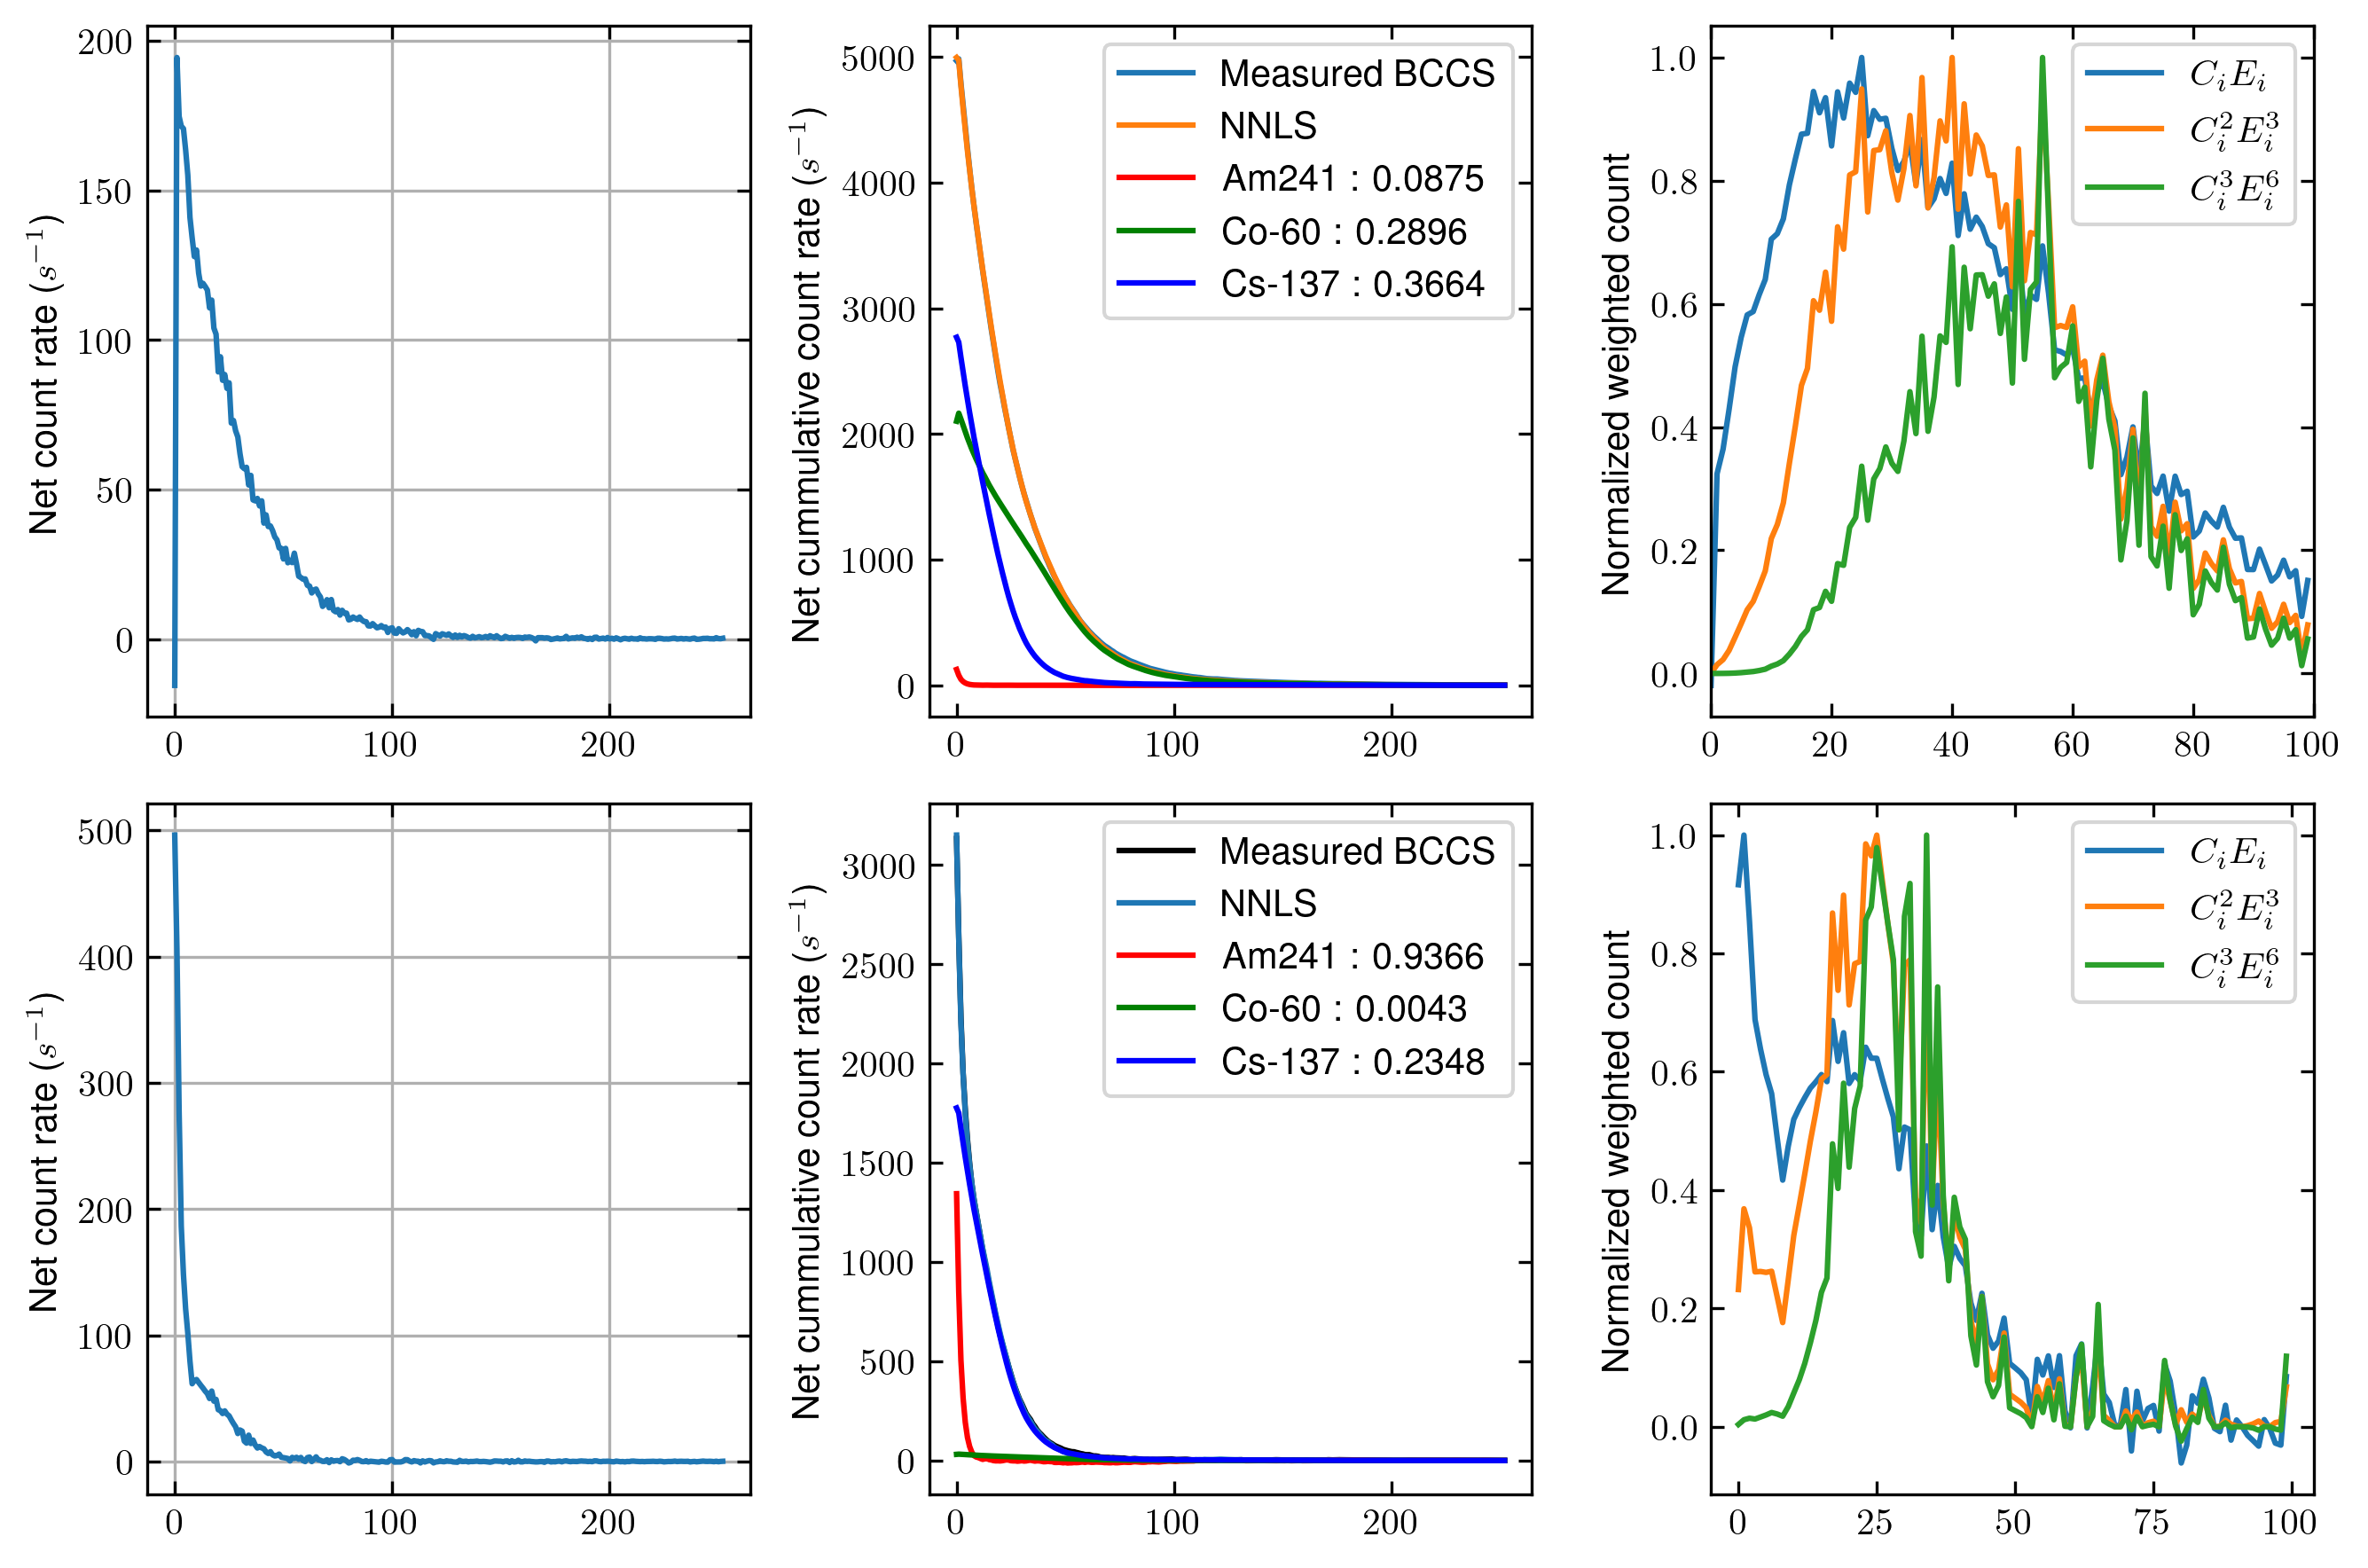

In [3]:
chn = np.arange(3,256)

plt.figure(figsize=(9, 6), dpi=300)
plt.subplot(231)
plt.plot((Specs1["co_cs_136"]-Specs1["bkg"])/20)
plt.grid()
plt.ylabel("Net count rate ($s^{-1}$)")

plt.subplot(232)
sample_bccs = bccs((Specs1["co_cs_136"]-Specs1["bkg"])/20)
ref_am_bccs = bccs((Specs1["am_80"]-Specs1["bkg"])/20)
ref_co_bccs = bccs((Specs1["co_60"]-Specs1["bkg"])/20)
ref_cs_bccs = bccs((Specs1["cs_70"]-Specs1["bkg"])/20)
nnls = ref_am_bccs * 0.0875 + ref_co_bccs * 0.2896 + ref_cs_bccs * 0.3664
plt.plot(sample_bccs, label="Measured BCCS")
plt.plot(nnls, label="NNLS")
plt.plot(ref_am_bccs*0.0875, color="red", label="Am241 : 0.0875")
plt.plot(ref_co_bccs*0.2896, color="green", label="Co-60 : 0.2896")
plt.plot(ref_cs_bccs*0.3664, color="blue", label="Cs-137 : 0.3664")
plt.ylabel("Net cummulative count rate ($s^{-1}$)")
plt.legend()

plt.subplot(233)
_data = ((Specs1["co_cs_136"]-Specs1["bkg"])/20)[0:100]
chn = chn[0:100]
tt = _data*chn
plt.plot(tt/max(tt), label = "$C_iE_i$")
tt =(_data**2)*(chn**3)
plt.plot(tt/max(tt), label = "$C_i^2E_i^3$")
tt =(_data**3)*(chn**6)
plt.plot(tt/max(tt), label = "$C_i^3E_i^6$")
plt.xlim(0, 100)
plt.ylabel("Normalized weighted count")
plt.legend()



plt.subplot(234)
plt.plot((Specs1["am_85_cs_173"]-Specs1["bkg"])/20)
plt.grid()
plt.ylabel("Net count rate ($s^{-1}$)")
plt.subplot(235)
sample_bccs = bccs((Specs1["am_85_cs_173"]-Specs1["bkg"])/20)
ref_am_bccs = bccs((Specs1["am_80"]-Specs1["bkg"])/20)
ref_co_bccs = bccs((Specs1["co_60"]-Specs1["bkg"])/20)
ref_cs_bccs = bccs((Specs1["cs_70"]-Specs1["bkg"])/20)
nnls = ref_am_bccs * 0.9366 + ref_co_bccs * 0.0043 + ref_cs_bccs * 0.2348
plt.plot(sample_bccs, color="black", label="Measured BCCS")
plt.plot(nnls, label="NNLS")
plt.plot(ref_am_bccs*0.9366, color="red", label="Am241 : 0.9366")
plt.plot(ref_co_bccs*0.0043, color="green", label="Co-60 : 0.0043")
plt.plot(ref_cs_bccs*0.2349, color="blue", label="Cs-137 : 0.2348")
plt.ylabel("Net cummulative count rate ($s^{-1}$)")
plt.legend()

plt.subplot(236)
_data = ((Specs1["am_85_cs_173"]-Specs1["bkg"])/20)[0:100]
tt = _data*chn
plt.plot(tt/max(tt), label = "$C_iE_i$")
tt =(_data**2)*(chn**3)
plt.plot(tt/max(tt), label = "$C_i^2E_i^3$")
tt =(_data**3)*(chn**6)
plt.plot(tt/max(tt), label = "$C_i^3E_i^6$")
plt.ylabel("Normalized weighted count")
plt.legend()

plt.tight_layout()

# Heavner 2013

In [4]:
Bi = np.cumsum(Specs1["bkg"])
Coi = np.cumsum(Specs1["co_60"])
Csi = np.cumsum(Specs1["cs_70"])
Ami = np.cumsum(Specs1["am_80"])
M_am = Ami/np.sqrt(Bi)
M_co = Coi/np.sqrt(Bi)
M_cs = Csi/np.sqrt(Bi)

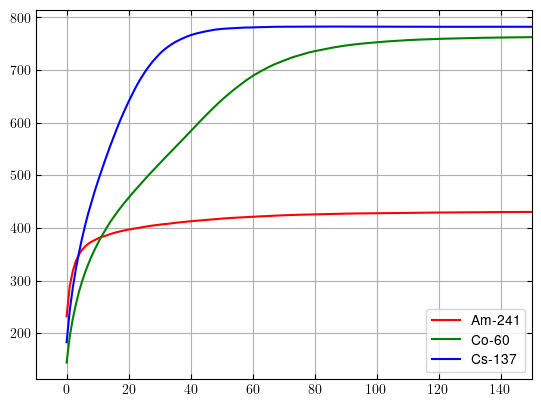

In [5]:
plt.plot(M_am, color="red", label="Am-241")
plt.plot(M_co, color="green", label = "Co-60")
plt.plot(M_cs, color="blue", label= "Cs-137")
plt.legend()
#plt.semilogy()
plt.xlim(-10, 150)
plt.grid(True)

In [6]:
np.sqrt(np.cumsum([1,2,3,4,5]))

array([1.        , 1.73205081, 2.44948974, 3.16227766, 3.87298335])

In [7]:
np.sqrt(10)

np.float64(3.1622776601683795)

In [28]:
RR={}
qs=list(Specs1.keys())
qs.remove('bkg')
for kk in qs :
    RR[kk] = Specs1[kk] - Specs1['bkg']
RR = pd.DataFrame(RR)

In [35]:
RR.sum()

am_80             28696.0
cs_70            151193.0
cs_130            60193.0
co_120            53257.0
co_60            145139.0
co_cs_136         99413.0
am_co_287         14263.0
co_cs_361         18533.0
am_cs_163         51065.0
am_co_cs_309      26861.0
am_210_co_153     40811.0
co_285_cs_367     21774.0
am_85_cs_173      62655.0
co_316_cs_223     31968.0
dtype: float64